In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# DISCRETE-ADAM

In [3]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(c_value,)
    )

print(f"Final value of theta: {theta_history[-1]}")


Epoch: 50, theta=-1.495001e+00, Error: 9.994873e-05
Epoch: 100, theta=-1.490007e+00, Error: 9.979714e-05
Epoch: 150, theta=-1.485023e+00, Error: 9.955257e-05
Epoch: 200, theta=-1.480053e+00, Error: 9.922642e-05
Epoch: 250, theta=-1.475102e+00, Error: 9.883249e-05
Epoch: 300, theta=-1.470171e+00, Error: 9.838524e-05
Epoch: 350, theta=-1.465264e+00, Error: 9.789839e-05
Epoch: 400, theta=-1.460382e+00, Error: 9.738400e-05
Epoch: 450, theta=-1.455527e+00, Error: 9.685207e-05
Epoch: 500, theta=-1.450698e+00, Error: 9.631048e-05
Epoch: 550, theta=-1.445896e+00, Error: 9.576521e-05
Epoch: 600, theta=-1.441122e+00, Error: 9.522061e-05
Epoch: 650, theta=-1.436375e+00, Error: 9.467975e-05
Epoch: 700, theta=-1.431654e+00, Error: 9.414473e-05
Epoch: 750, theta=-1.426961e+00, Error: 9.361692e-05
Epoch: 800, theta=-1.422293e+00, Error: 9.309719e-05
Epoch: 850, theta=-1.417651e+00, Error: 9.258605e-05
Epoch: 900, theta=-1.413035e+00, Error: 9.208374e-05
Epoch: 950, theta=-1.408443e+00, Error: 9.15903

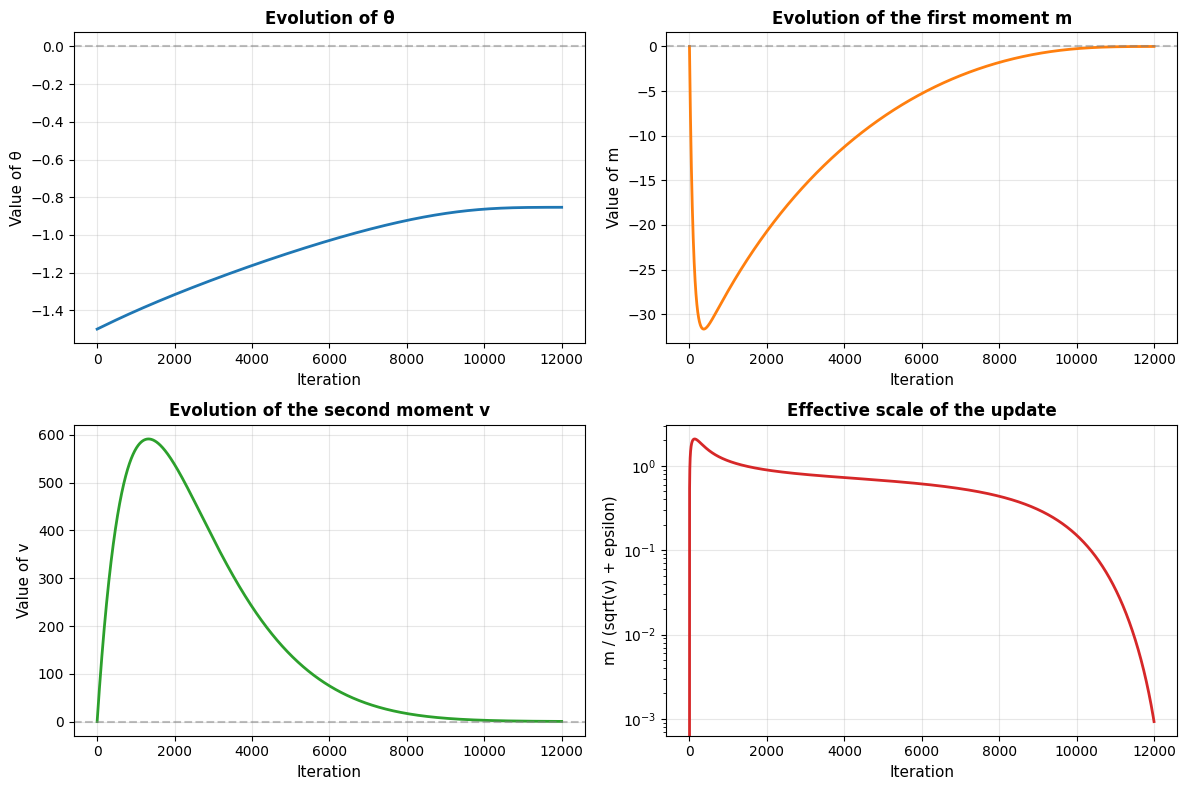

In [4]:
# Create Plotter and visualize
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plot all
plotter.plot('all')
plt.show()

## Save Results

In [5]:
# Create DataFrame
df_discrete = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': None,
    'theta_ddot_history': None,
    'm_history': m_history,
    'v_history': v_history
})

# Save to CSV
df_discrete.to_csv(f'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_discrete)}")

Results saved in 'results/c_4.0_results_initial_theta_-1.5_lr_0.0001_beta1_0.99_beta2_0.999.csv'
Total rows: 12000
